In [1]:
import numpy
import scipy
import matplotlib.pyplot as plt
import matplotlib

#### bayesian densities

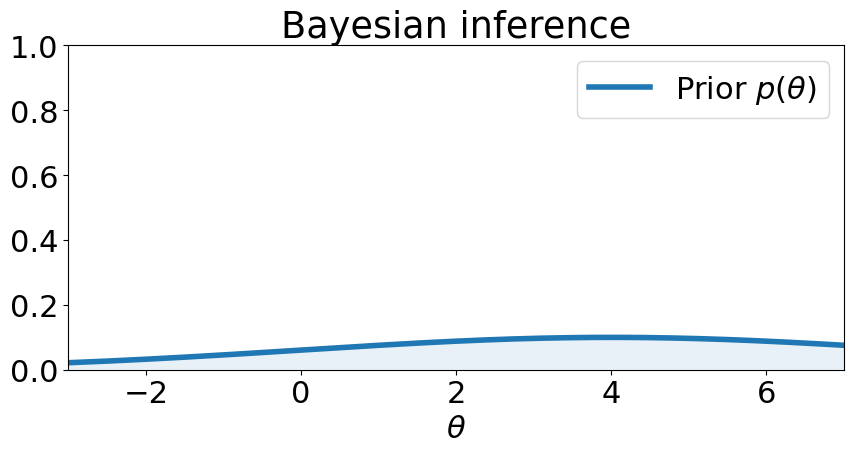

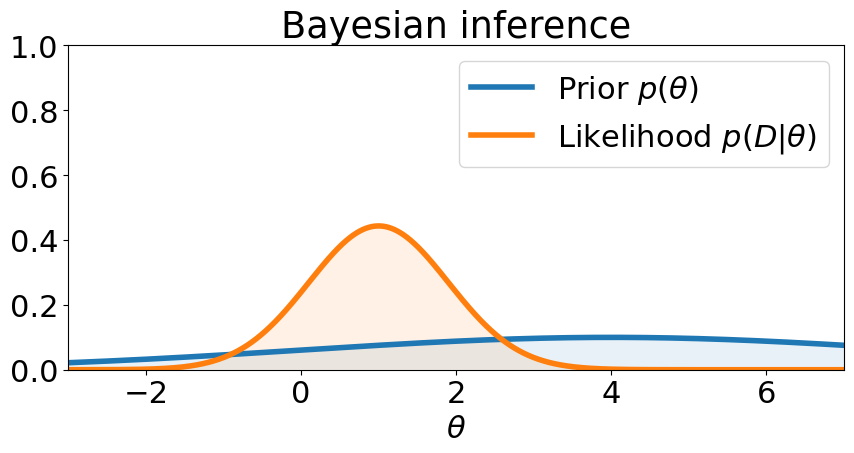

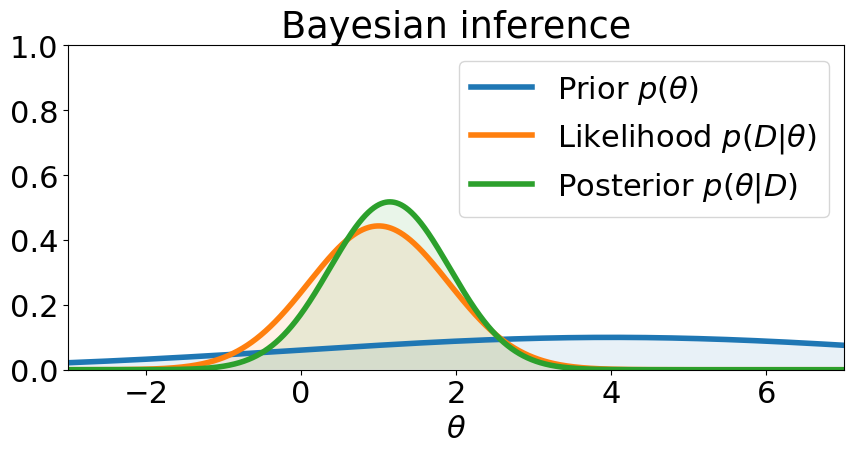

In [40]:
# prob params
priorParams = (4, 4)
likeParams = (1, 0.9)
posteriorParams = (
    (priorParams[1]**2 * likeParams[0] + likeParams[1]**2 * priorParams[0]) / (priorParams[1]**2 + likeParams[1]**2),
    (priorParams[1]**2 * likeParams[1]**2) / (priorParams[1]**2 + likeParams[1]**2),
)

# plot params
xLim = (-3,7)
yLim = (0,1)
dx = 1/500
xs = numpy.linspace (xLim[0], xLim[1], (xLim[1]-xLim[0])*int(1/dx))

# compute densities
priorYs = scipy.stats.norm.pdf (xs, loc=priorParams[0], scale=priorParams[1])
likeYs = scipy.stats.norm.pdf (likeParams[0], loc=xs, scale=likeParams[1])
posteriorYs = scipy.stats.norm.pdf (xs, loc=posteriorParams[0], scale=posteriorParams[1])
# i think this renormalizing does not work if not all densities in range
# posteriorYs = priorYs * likeYs
# posteriorYs /= (posteriorYs*dx).sum()

plotScenarios = [
    "prior",
    "likelihood",
    "posterior",
]

for thisScenario in plotScenarios:

    # text size
    matplotlib.rcParams["font.size"] = 22
    (fig, ax) = plt.subplots (figsize=(9,5))

    # plot prior
    ax.plot (xs, priorYs, label=r"Prior $p(\theta)$", lw=4)
    ax.fill_between (xs, priorYs, alpha=0.1)

    # plot likelihood
    if (thisScenario in ["likelihood", "posterior"]):
        ax.plot (xs, likeYs, label=r"Likelihood $p(D|\theta)$", lw=4)
        ax.fill_between (xs, likeYs, alpha=0.1)

    # plot posterior
    if (thisScenario == "posterior"):
        ax.plot (xs, posteriorYs, label=r"Posterior $p(\theta|D)$", lw=4)
        ax.fill_between (xs, posteriorYs, alpha=0.1)

    # pretty plot
    ax.set_ylim (yLim)
    ax.set_xlim (xLim)
    # ax.set_ylabel ("f(x)")
    ax.set_xlabel (r"$\theta$")
    ax.set_title ("Bayesian inference")
    ax.legend()

    # save plot
    plt.tight_layout()
    plt.savefig (f"bayesian_{thisScenario}.pdf")